In [15]:
import numpy as np
import requests
from skyfield.api import EarthSatellite, load, wgs84, utc
from skyfield.framelib import itrs
from skyfield.functions import rot_z
import datetime as dt
from time import perf_counter
import matplotlib.pyplot as plt

In [16]:
tlesource = requests.get("https://celestrak.org/NORAD/elements/gp.php?GROUP=active").text.strip().split("\n")
tles = [tlesource[i:i+3] for i in range(0, len(tlesource), 3)]
print(f"Loaded {len(tles)} TLEs")

def get_tle(sat_name):
    for tle in tles:
        if tle[0].strip() == sat_name:
            return tle
    return None

Loaded 14147 TLEs


In [17]:
def propagate_fg_elliptic(
    sat_gcrs,
    t_sf,
    t_required,
    max_iter=10,
    tol=1e-12,
):
    if t_required.tt == t_sf.tt:
        return sat_gcrs.position.km, sat_gcrs.velocity.km_per_s
    mu = 3.986004418*10**5

    r0 = sat_gcrs.position.km
    v0 = sat_gcrs.velocity.km_per_s

    r0_norm = np.linalg.norm(r0)
    v0_norm = np.linalg.norm(v0)

    dt = (t_required.tt - t_sf.tt) * 86400.0

    energy = 0.5 * v0_norm**2 - mu / r0_norm
    assert energy < 0.0, "Orbit is not elliptic"

    a = -mu / (2.0 * energy)
    n = np.sqrt(mu / a**3)
    rv_dot = np.dot(r0, v0)
    sqrt_mu_a = np.sqrt(mu * a)

    DeltaE = n * dt

    for _ in range(max_iter):
        sinE = np.sin(DeltaE)
        cosE = np.cos(DeltaE)
        
        F = (
            DeltaE
            - (1.0 - r0_norm / a) * sinE
            + (rv_dot / sqrt_mu_a) * (1.0 - cosE)
            - n * dt
        )
        dF = (
            1.0
            - (1.0 - r0_norm / a) * cosE
            + (rv_dot / sqrt_mu_a) * sinE
        )
        dE = -F / dF
        DeltaE += dE
        if abs(dE) < tol:
            break

    # f and g functions
    sinE = np.sin(DeltaE)
    cosE = np.cos(DeltaE)

    f = 1.0 - (a / r0_norm) * (1.0 - cosE)
    g = dt + (1.0 / n) * (sinE - DeltaE)

    r = f * r0 + g * v0
    r_norm = np.linalg.norm(r)

    fdot = -(sqrt_mu_a / (r_norm * r0_norm)) * sinE
    
    gdot = 1.0 - (a / r_norm) * (1.0 - cosE)
    v = fdot * r0 + gdot * v0
    return r, v

def init_earth_rotation(station, t_ref):
    r0_itrs = station.itrs_xyz.km
    R_gcrs2itrs = itrs.rotation_at(t_ref)
    R_itrs2gcrs = R_gcrs2itrs.T
    
    return r0_itrs, R_itrs2gcrs

def propagate_earth_rotation(r_itrs, R_itrs2gcrs, t_sf, t_required):
    omega_earth = 7.2921150e-5
    dt_sec = (t_required.tt - t_sf.tt) * 86400.0
    
    angle = omega_earth * dt_sec
    c, s = np.cos(angle), np.sin(angle)
    x, y, z = r_itrs
    
    r_rotated = np.array([
        x*c - y*s,
        x*s + y*c,
        z
    ])
    return R_itrs2gcrs @ r_rotated


In [18]:
def enu_from_ecef(delta, lat_deg, lon_deg):
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    sin_lat, cos_lat = np.sin(lat), np.cos(lat)
    sin_lon, cos_lon = np.sin(lon), np.cos(lon)

    east  = np.array([-sin_lon,           cos_lon,          0.0])
    north = np.array([-sin_lat*cos_lon,  -sin_lat*sin_lon,  cos_lat])
    up    = np.array([ cos_lat*cos_lon,   cos_lat*sin_lon,  sin_lat])

    x_e = np.dot(east,  delta)
    x_n = np.dot(north, delta)
    x_u = np.dot(up,    delta)

    rng = np.linalg.norm(delta)
    el  = np.degrees(np.arctan2(x_u, np.hypot(x_e, x_n)))
    az  = (np.degrees(np.arctan2(x_e, x_n)) + 360.0) % 360.0
    return el, az, rng

3.626608840475532e-05
3.660775812198425e-05
3.509060164879342e-05
3.5132669693617464e-05
3.52320188727949e-05
3.538815510769329e-05
3.5600302072110325e-05
3.586751995516323e-05
3.6188542949288915e-05
3.4819140069026676e-05
3.483617355770133e-05
3.491104099679446e-05
3.504336685300539e-05
3.523250933985495e-05
3.5477571286195805e-05
3.577735496319688e-05
3.613056990410623e-05
3.455059497422188e-05
3.460051892822101e-05
3.470855955377929e-05
3.487414363703852e-05
3.5096501897528065e-05
3.537452602674273e-05
3.5706926900078805e-05
3.4276221811576846e-05
3.430076246442996e-05
3.438400910771317e-05
3.452553591104981e-05
3.472464790908551e-05
3.498033275685899e-05
3.5291369570195225e-05
3.565633559613593e-05
3.4012053529754406e-05
3.4070039294388514e-05
3.418697114891452e-05
3.436228423652411e-05
3.459507530672954e-05
3.4884153240537135e-05
3.5228202014664696e-05
3.373469161556926e-05
3.3766937145044294e-05
3.3858781054609186e-05
3.400975455361141e-05
3.421905268012099e-05
3.448562286359301e

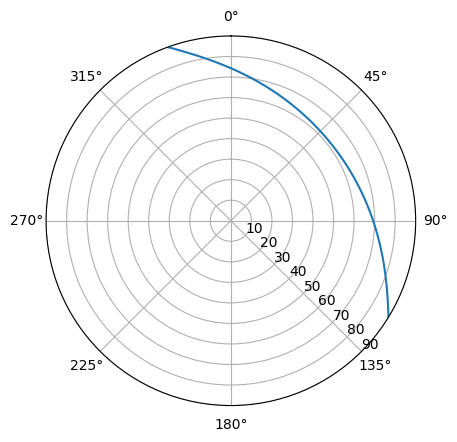

In [ ]:
t = np.datetime64('2026-01-16T16:36:07')
propagatingsat = get_tle('METEOR-M2 3')
lat = 55.7
lon = 37.1
height = 170

ts = load.timescale()
t_py = dt.datetime.fromtimestamp(t.astype('datetime64[us]').astype('int') / 1e6, utc).replace(tzinfo=utc)
t_sf = ts.from_datetime(t_py)

station = wgs84.latlon(
    latitude_degrees=lat,
    longitude_degrees=lon,
    elevation_m=height,
)
observer_gcrs = station.at(t_sf)

name, line1, line2 = propagatingsat
satellite = EarthSatellite(line1, line2, name, ts)
sat_gcrs = satellite.at(t_sf)
r0_itrs, R_matrix = init_earth_rotation(station, t_sf)

t = perf_counter()
time_seconds = range(-1000, 1000)
azimuths = []
elevations = []
range_rates = []

for i in time_seconds:
    t_i = ts.from_datetime(t_py + dt.timedelta(seconds=i))
    r_i, v_i = propagate_fg_elliptic(sat_gcrs=sat_gcrs, t_sf=t_sf, t_required=t_i)
    r_station_gcrs = propagate_earth_rotation(r0_itrs, R_matrix, t_sf, t_i)
    #print(np.linalg.norm(r_station_gcrs - station.at(t_i).position.km))
    delta = r_i - r_station_gcrs
    el_i, az_i, rng_i = enu_from_ecef(delta, lat, lon)
    elevations.append(el_i)
    azimuths.append(az_i)
    range_rates.append(np.dot(delta, v_i) / rng_i)
t2 = perf_counter()
print(f"Propagation time: {t2 - t:.6f} seconds")


# plt.plot(time_seconds, range_rates)
# plt.show()
# plt.plot(time_seconds, elevations)
# plt.show()
# plt.plot(time_seconds, azimuths)
# plt.show()

plt.figure()
ax = plt.subplot(111, projection='polar')
azimuths_rad = np.radians(azimuths)
elevations_plot = [90 - el for el in elevations]
ax.plot(azimuths_rad, elevations_plot)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rlabel_position(135)
ax.set_rlim(0, 90)
plt.show()